# Quick Example
In this notebook, we are going to see how to quickly use `dfcosmic` for cosmic ray removal using the original HST WFC data from van Dokkum 2001. The parameters are set from that paper.

For a detailed comparison on this dataset for the different python implementations of cosmic ray removal, check out the HST.ipynb file.

In [1]:
from astropy.io import fits
import numpy as np
from dfcosmic import lacosmic
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

In [2]:
# Get data and pre-computed IRAF Mask
data = fits.getdata("./hst_im_ext3.fits").astype(np.float32)
iraf_mask = fits.getdata("./hst_im_ext3_iraf_mask.fits").astype(np.uint8)

In [3]:
# Compute dfcosmic mask
df_cosmic_result, df_cosmic_mask = lacosmic(
    data,
    sigclip=4.5,
    sigfrac=0.3,
    objlim=4,
    readnoise=5,
    gain=7,
    niter=4,
    device="cpu",
    use_cpp=True,
    verbose=False,
)

/tmp/ipykernel_35256/1015838363.py:5: RuntimeWarning: invalid value encountered in log10
  np.log10(data),


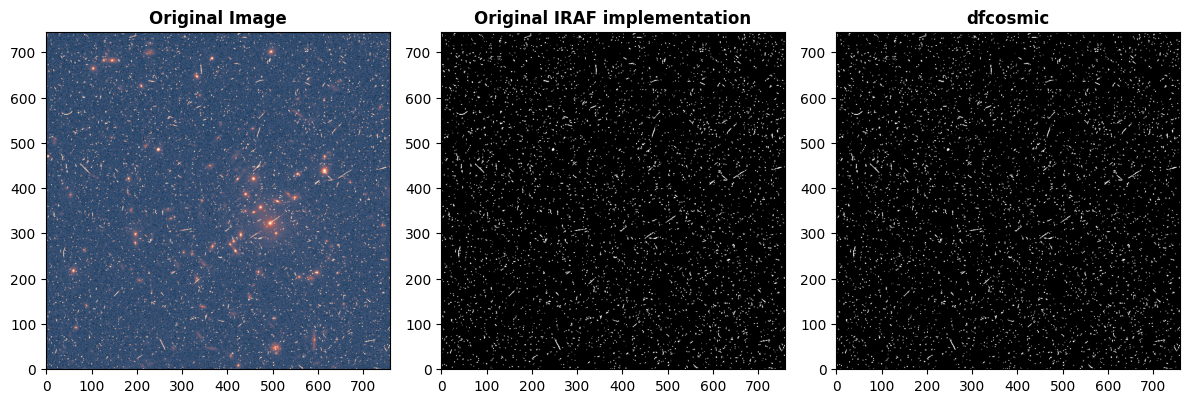

In [6]:
# Plot full image

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 8))
axs[0].imshow(
    np.log10(data),
    cmap=cmc.lipari,
    origin="lower",
    vmin=1,
    vmax=2,
)
axs[0].set_title("Original Image", fontweight="bold")

axs[1].imshow(iraf_mask, cmap=cmc.grayC, origin="lower")
axs[1].set_title("Original IRAF implementation", fontweight="bold")

axs[2].imshow(
    df_cosmic_mask, cmap=cmc.grayC, origin="lower"
)
axs[2].set_title("dfcosmic", fontweight="bold")


plt.tight_layout()
plt.savefig("example_hst.png", dpi=600)

/tmp/ipykernel_35256/2835566351.py:9: RuntimeWarning: invalid value encountered in log10
  np.log10(data)[y_min:y_max, x_min:x_max],


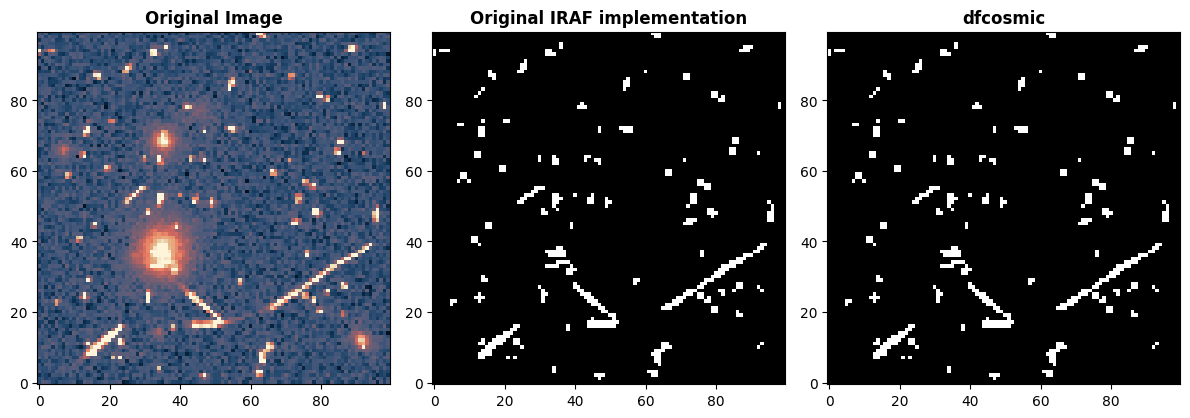

In [5]:
# Plot small region
x_min = 580
x_max = 680
y_min = 400
y_max = 500

fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 8))
axs[0].imshow(
    np.log10(data)[y_min:y_max, x_min:x_max],
    cmap=cmc.lipari,
    origin="lower",
    vmin=1,
    vmax=2,
)
axs[0].set_title("Original Image", fontweight="bold")

axs[1].imshow(iraf_mask[y_min:y_max, x_min:x_max], cmap=cmc.grayC, origin="lower")
axs[1].set_title("Original IRAF implementation", fontweight="bold")

axs[2].imshow(
    df_cosmic_mask[y_min:y_max, x_min:x_max], cmap=cmc.grayC, origin="lower"
)
axs[2].set_title("dfcosmic", fontweight="bold")


plt.tight_layout()
plt.savefig("example_hst.png", dpi=600)